## Plot of baselines



## Summarize results

In [16]:
from src.analysis import summarize_file

print("eta 1: ")
summarize_file("results/train_and_eval/eta1_optimal/user_ci_disabled/eta_1/test_eval_log.jsonl")
print("eta 0.75: ")
summarize_file("results/train_and_eval/eta_0.75_optimal/test_eval_log.jsonl")
print("eta 0.50: ")
summarize_file("results/train_and_eval/eta_0.5_optimal/test_eval_log.jsonl")
print("eta 0.25: ")
summarize_file("results/train_and_eval/session_20251021-192042Z-9fb245/user_ci_disabled/eta_0.01/test_eval_log.jsonl")

print("eta: 0.01")
summarize_file("results/ghs_sessions_20251020/delay_eta_0.25/user_ci_disabled/eta_0.25/test_eval_log.jsonl")
print("eta 0.0001")
summarize_file("results/ghs_sessions_20251020/delay_eta_0.0001/user_ci_disabled/eta_0.0001/test_eval_log.jsonl")

eta 1: 
Metric                                                       |            Mean |             Std
------------------------------------------------------------------------------------------------
Action Analysis.Fixed Delay Percentage                       |       64.971974 |       10.326843
Action Analysis.Fixed Delays.1200s                           |        5787.200 |        4342.256
Action Analysis.Fixed Delays.14400s                          |           102.5 |       52.930772
Action Analysis.Fixed Delays.1800s                           |        3574.000 |        6665.708
Action Analysis.Fixed Delays.2400s                           |        1754.500 |        1422.821
Action Analysis.Fixed Delays.300s                            |       41062.000 |       23379.303
Action Analysis.Fixed Delays.3600s                           |           275.4 |      404.354795
Action Analysis.Fixed Delays.600s                            |        7592.200 |        6458.760
Action Analysis.Fixed 

In [20]:
### Sparse rewards:
print("eta = 1")
summarize_file("results/train_and_eval/eta_1_sparse_rewards/user_ci_disabled/eta_1/test_eval_log.jsonl")
print("eta = 0.75")

print("eta = 0.5")
summarize_file("results/ghs_sessions_20251020/wait_abs_ems_0.50/user_ci_disabled/eta_0.5/test_eval_log.jsonl")

print("eta = 0.01")
summarize_file("results/ghs_sessions_20251020/wait_abs_ems_0.01/user_ci_disabled/eta_0.01/test_eval_log.jsonl")

eta = 1
Metric                                                       |            Mean |             Std
------------------------------------------------------------------------------------------------
Action Analysis.Fixed Delay Percentage                       |       57.253962 |       19.470468
Action Analysis.Fixed Delays.1200s                           |       10498.667 |       18118.444
Action Analysis.Fixed Delays.14400s                          |        4552.250 |        5508.347
Action Analysis.Fixed Delays.1800s                           |        5302.000 |        8394.705
Action Analysis.Fixed Delays.2400s                           |      794.333333 |        1235.655
Action Analysis.Fixed Delays.300s                            |       25732.000 |       32991.776
Action Analysis.Fixed Delays.3600s                           |             222 |      342.387208
Action Analysis.Fixed Delays.600s                            |       14152.000 |       11251.622
Action Analysis.Fixed 

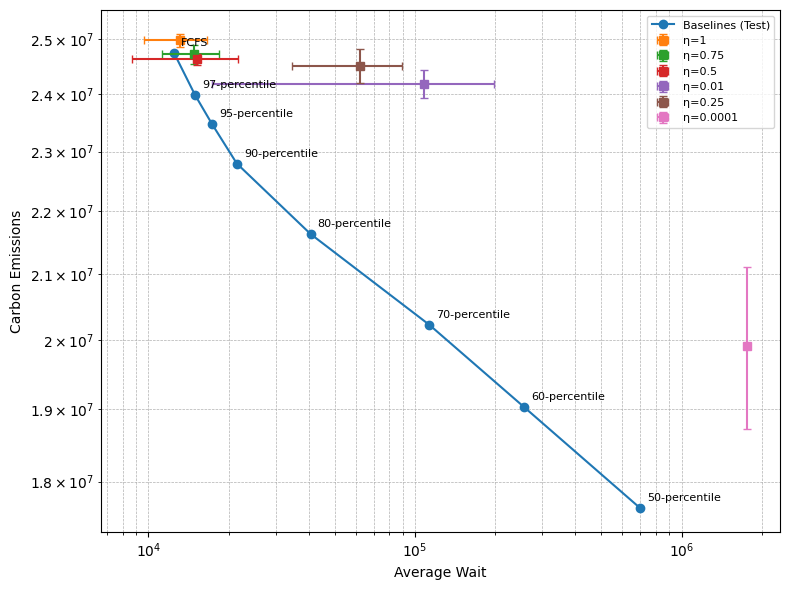

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# -----------------------------
# Baseline (Test Phase) data
# -----------------------------
baselines_order = [

    ("50-percentile",   701161.83, 17645590.39),
    ("60-percentile",   256969.73, 19022590.67),
    ("70-percentile",   113307.50, 20221244.13),
    ("80-percentile",    40573.39, 21633983.58),
    ("90-percentile",    21460.62, 22796113.69),
    ("95-percentile",    17332.36, 23473034.11),
    ("97-percentile",    14969.60, 23984053.75),
    ("FCFS",             12474.55, 24747898.11),
]

baseline_waits = np.array([b[1] for b in baselines_order], dtype=float)
baseline_carbons = np.array([b[2] for b in baselines_order], dtype=float)
# -----------------------------
# Model seed-level data
# -----------------------------
models_raw = {
    "η=1": {
        "waits":  [10511, 19251, 12614, 11575, 11762],
        "carbons":[24977084, 25063805, 25111206, 24961711, 24796468],
    },
    "η=0.75": {
        "waits":  [19858, 12984, 14536, 11863],
        "carbons":[24819627, 24759467, 24460210, 24847822],
    },
    "η=0.5": {
        "waits":  [10369, 13167, 26021, 10384, 15955],
        "carbons":[24557999, 24630306, 24812178, 24585198, 24561828],
    },
    "η=0.01": {
        "waits":  [ 60424, 74887, 242507, 52871],
        "carbons":[ 24220308, 24525918, 23977348, 24013566],
    },
    "η=0.25": {
        "waits":  [30610, 89360, 72623, 35027, 83264],
        "carbons":[24486441, 24008054, 24816979, 24584249, 24657118],
    },
    "η=0.0001": {
        "waits":  [1744321, 1784438],
        "carbons":[19063318, 20755364],
    },
}


# Aggregate means and stds
summary_rows = []
for label, vals in models_raw.items():
    waits = np.array(vals["waits"], dtype=float)
    carbs = np.array(vals["carbons"], dtype=float)
    summary_rows.append({
        "model": label,
        "wait_mean": waits.mean(),
        "wait_std": waits.std(ddof=1),
        "carbon_mean": carbs.mean(),
        "carbon_std": carbs.std(ddof=1),
        "n_seeds": len(waits),
    })
models_summary = pd.DataFrame(summary_rows)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# Baselines
ax.plot(baseline_waits, baseline_carbons, marker="o", linestyle="-", label="Baselines (Test)")
for label, x, y in baselines_order:
    ax.annotate(label, (x, y), xytext=(5, 5), textcoords="offset points", fontsize=8)

# Models with error bars
for _, r in models_summary.iterrows():
    ax.errorbar(
        r["wait_mean"],
        r["carbon_mean"],
        xerr=r["wait_std"],
        yerr=r["carbon_std"],
        fmt="s",
        capsize=3,
        label=r["model"],
    )

ax.set_xlabel("Average Wait")
ax.set_ylabel("Carbon Emissions")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(loc="best", fontsize=8)
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

## Linear regression

## Run best waittime dense

In [4]:
from src.analysis import (
    evaluate_models,
    evaluate_baselines,
    wait_time_distributions_vs_baseline,
    plot_wait_time_distributions_for_seeds,
    plot_wait_time_boxplots_for_seeds,
    build_wait_size_heatmap_for_seed,
    build_wait_size_heatmap_for_fcfs,
    build_wait_size_heatmaps_for_seed_vs_fcfs,
    plot_wait_size_heatmaps,
)
from src.metrics import collect_wait_times
from src.viz_style import use_house_style
import numpy as np

use_house_style()

train_and_eval_folder = "results/train_and_eval/eta1_optimal/user_ci_disabled/eta_1"
seeds = [1]

model_eval = evaluate_models(
    train_eval_dir=train_and_eval_folder,
    seeds=seeds,
    mode="test",
    n_eval_episodes=1,
)

baseline_eval = evaluate_baselines(
    train_eval_dir=train_and_eval_folder,
    mode="test",
    n_eval_episodes=1,
    include_percentiles=False,
)


ImportError: cannot import name 'evaluate_models' from 'src.analysis' (/Users/mikkeldahl/green-hpc-scheduler/src/analysis.py)

In [ ]:
def _collect_waits(raw_stats: dict[str, dict[str, list]], key: str) -> list[float]:
    waits: list[float] = []
    for history in raw_stats[key]["job_scheduled_history"]:
        waits.extend(collect_wait_times(history))
    return waits

waits_model: list[float] = []
for seed_stats in model_eval.values():
    waits_model.extend(_collect_waits(seed_stats["raw"], "model"))

waits_baseline = _collect_waits(baseline_eval["raw"], "FCFS Baseline")

positive_samples = [w for w in waits_model + waits_baseline if w > 0]
if positive_samples:
    upper_clip = float(np.percentile(positive_samples, 99))
    value_range = (0.0, upper_clip)
else:
    value_range = None

value_range


(0.0, 285159.64000000234)

In [ ]:
distributions = wait_time_distributions_vs_baseline(
    train_eval_dir=train_and_eval_folder,
    model_stats=model_eval,
    baseline_raw_stats=baseline_eval["raw"],
    baseline_key="FCFS Baseline",
    bins="fd",
    normalize=True,
    value_range=value_range,
)


In [ ]:
seed, distribution = next(iter(distributions.items()))
distribution['model']['summary'], distribution['FCFS Baseline']['summary']


({'count': 22341,
  'mean': 10511.272592990466,
  'median': 0.0,
  'min': 0.0,
  'max': 1532152.0,
  'p90': 20313.0,
  'p95': 45615.0,
  'zero_fraction': 0.5881115437983976},
 {'count': 22341,
  'mean': 12474.54858779822,
  'median': 0.0,
  'min': 0.0,
  'max': 732464.0,
  'p90': 40116.0,
  'p95': 74055.0,
  'zero_fraction': 0.604091132894678})

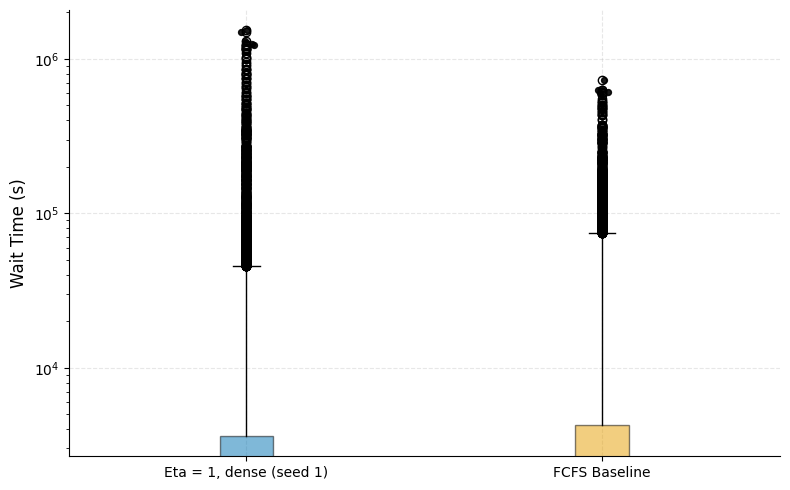

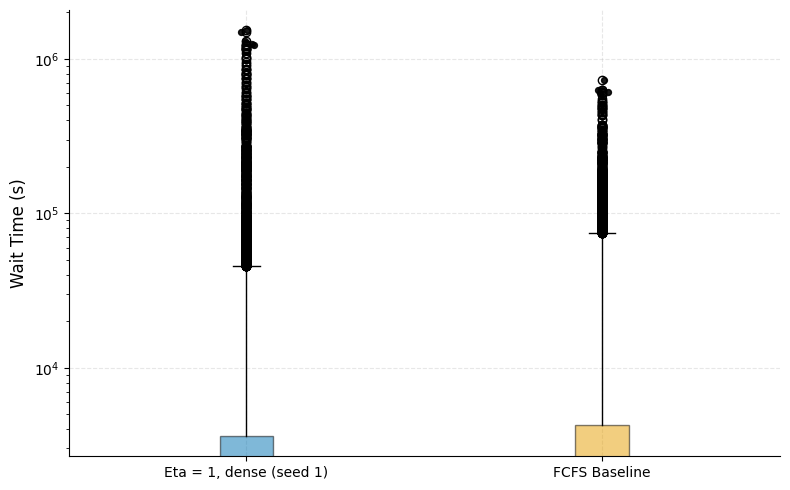

In [ ]:
ax_box = plot_wait_time_boxplots_for_seeds(
    train_eval_dir=train_and_eval_folder,
    distributions=distributions,
    baseline_key="FCFS Baseline",
    baseline_label="FCFS Baseline",
    model_label="Eta = 1, dense",
    figsize=(8.0, 5.0),
    whis=(5, 95),
    showfliers=True,
    log_scale=True,
    show=False,
)
ax_box.figure


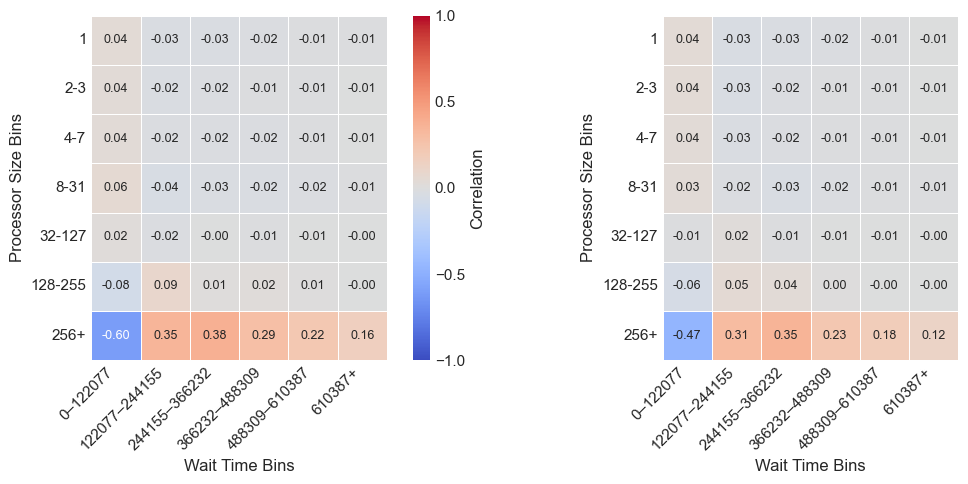

In [ ]:
hm_model, hm_fcfs = build_wait_size_heatmaps_for_seed_vs_fcfs(
    train_eval_dir=train_and_eval_folder,
    model_eval=model_eval,
    baseline_eval=baseline_eval,
    seed=1,
    size_metric="procs",
    x_bins=40,
    y_bins="fd",
    density=False,
)
axes_heatmap = plot_wait_size_heatmaps(
    [hm_model, hm_fcfs],
    labels=None,
    share_colorbar=True,
    show=False,
)


/Users/mikkeldahl/green-hpc-scheduler/src/validation.py:1146: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.savefig(png_path, dpi=150)
/Users/mikkeldahl/green-hpc-scheduler/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


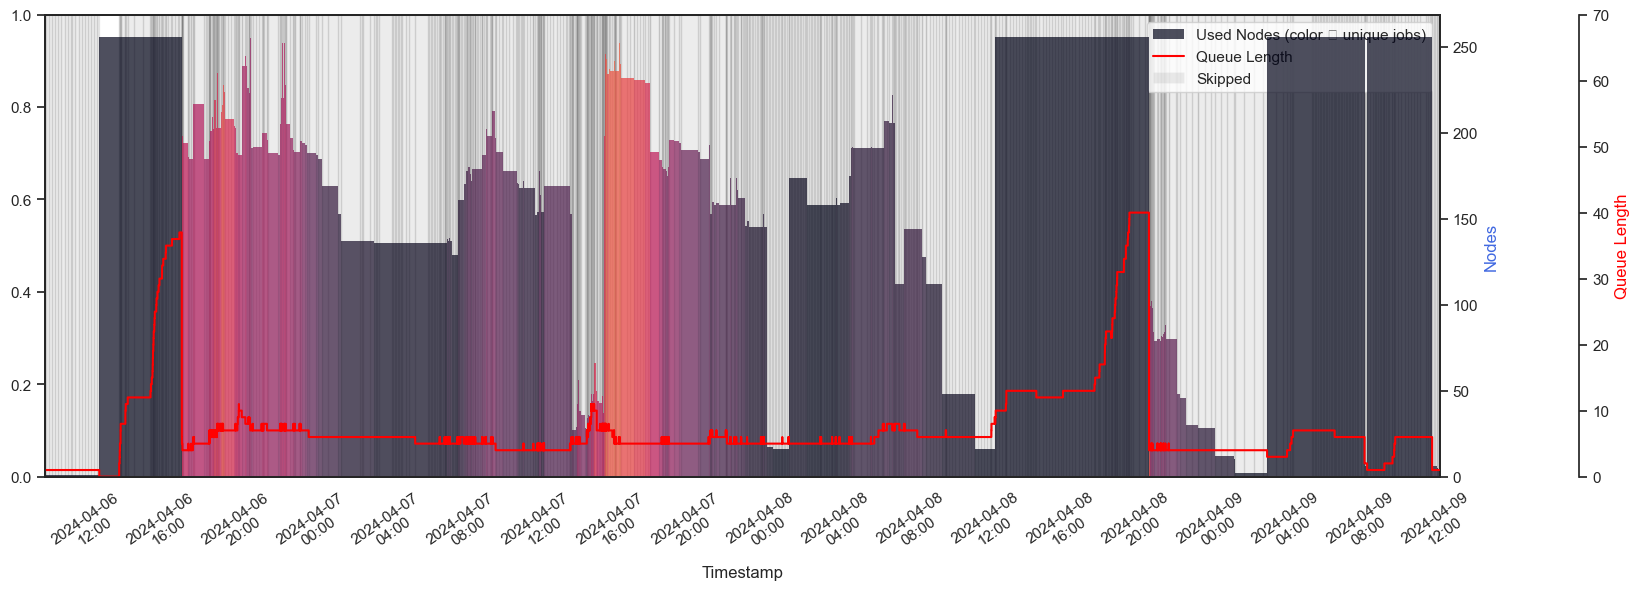

('renderings/seed_3_eta_0.5.png', <Figure size 1800x600 with 3 Axes>)

/Users/mikkeldahl/green-hpc-scheduler/.venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  func(*args, **kwargs)


In [ ]:
from src.validation import Validation
val = Validation()
val.load_dir(model_dir=train_and_eval_folder)
val.render_timeseries_plot(model_eval[1]["raw"]['model']['action_traces'], start_time = 3600*24*5.4, end_time = 3600*24*8.5, name = "seed_3_eta_0.5",  display_carbon_itensity=False, max_queue_length=70, calendar_split="test")

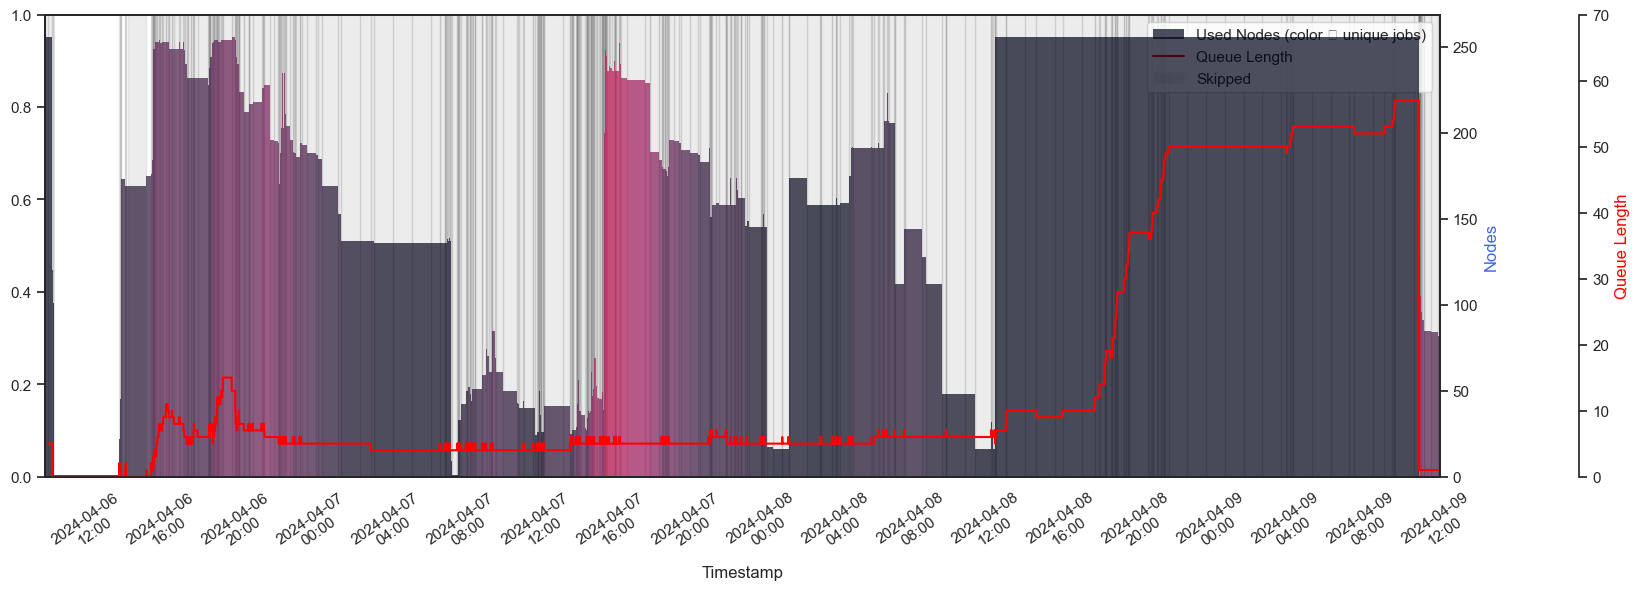

('renderings/seed_3_eta_0.5.png', <Figure size 1800x600 with 3 Axes>)

In [ ]:
val.render_timeseries_plot(baseline_eval["raw"]['FCFS Baseline']['action_traces'], start_time = 3600*24*5.4, end_time = 3600*24*8.5, name = "seed_3_eta_0.5",display_carbon_itensity=False, max_queue_length=70, calendar_split="test")

## Optimizing Carbon

#### Linear regression

In [ ]:
import statsmodels.api as sm
# --- Build a flat DataFrame of observations (one row per seed result) ---
rows = []
for k, v in models_raw.items():
    # parse eta value from label like "η=0.75"
    eta = float(k.split('=')[1].strip())
    waits = v["waits"]
    carbs = v["carbons"]
    if len(waits) != len(carbs):
        raise ValueError(f"Length mismatch for {k}: waits={len(waits)} vs carbons={len(carbs)}")
    for w, c in zip(waits, carbs):
        rows.append({"eta": eta, "wait": float(w), "carbon": float(c)})

df = pd.DataFrame(rows)
print(f"Built dataset with {len(df)} observations across {df['eta'].nunique()} eta levels.")
print(df.groupby('eta')[['wait','carbon']].agg(['mean','std','count']).round(2))

# --- Helper to fit OLS with robust SE and print a compact summary ---
def fit_and_report(y, y_name, X, add_quad=False, log10=False):
    X_mat = pd.DataFrame({"eta": X})
    if add_quad:
        X_mat["eta2"] = X_mat["eta"]**2
    X_mat = sm.add_constant(X_mat)
    target = np.log10(y) if log10 else y

    model = sm.OLS(target, X_mat).fit(cov_type="HC3")

    # slope(s) and CI
    params = model.params
    conf = model.conf_int()
    r2 = model.rsquared

    print("\n" + ("-"*72))
    tag = f"{y_name} ~ eta" + (" + eta^2" if add_quad else "")
    if log10:
        tag += "  (log10 target)"
    print(tag)
    print("-"*72)
    print(f"n = {len(y)}   R^2 = {r2:.4f}")
    for name in params.index:
        if name == "const": 
            continue
        p = model.pvalues[name]
        lo, hi = conf.loc[name].tolist()
        print(f"{name:>6s}:  coef = {params[name]: .6g},  p = {p:.4g},  95% CI [{lo:.6g}, {hi:.6g}]")

    return model

# --- Regressions ---
# Linear in eta
m_wait_lin  = fit_and_report(df["wait"].values,   "wait",   df["eta"].values, add_quad=False, log10=False)
m_carb_lin  = fit_and_report(df["carbon"].values, "carbon", df["eta"].values, add_quad=False, log10=False)

# Optional: quadratic term (uncomment if you suspect nonlinearity)
# m_wait_quad = fit_and_report(df["wait"].values,   "wait",   df["eta"].values, add_quad=True,  log10=False)
# m_carb_quad = fit_and_report(df["carbon"].values, "carbon", df["eta"].values, add_quad=True,  log10=False)

# Log10 targets to mitigate heavy tails (waits especially)
m_wait_log  = fit_and_report(df["wait"].values,   "wait",   df["eta"].values, add_quad=False, log10=True)
m_carb_log  = fit_and_report(df["carbon"].values, "carbon", df["eta"].values, add_quad=False, log10=True)

Built dataset with 25 observations across 6 eta levels.
              wait                      carbon                  
              mean       std count        mean         std count
eta                                                             
0.0001  1764379.50  28367.00     2  19909341.0  1196457.20     2
0.0100   107672.25  90352.75     4  24184285.0   251647.02     4
0.2500    62176.80  27505.88     5  24510568.2   305735.15     5
0.5000    15179.20   6487.05     5  24629501.8   106097.20     5
0.7500    14810.25   3539.14     4  24721781.5   178231.87     4
1.0000    13142.60   3495.74     5  24982054.8   120669.14     5

------------------------------------------------------------------------
wait ~ eta
------------------------------------------------------------------------
n = 25   R^2 = 0.1963
   eta:  coef = -577447,  p = 0.07923,  95% CI [-1.22227e+06, 67371.7]

------------------------------------------------------------------------
carbon ~ eta
---------------------

In [ ]:
## 0.50

model_eval_eta_mid = evaluate_models(
    train_eval_dir="results/ghs_sessions_20251020/delay_eta_0.5/user_ci_disabled/eta_0.5",
    seeds=[1],
    mode="test",
    n_eval_episodes=1,
)

## 0.01
model_eval_eta_low = evaluate_models(
    train_eval_dir="results/ghs_sessions_20251020/delay_eta_0.01/user_ci_disabled/eta_0.01",
    seeds=[4],
    mode="test",
    n_eval_episodes=1,
)
## 0.0001
model_eval_eta_very_low = evaluate_models(
    train_eval_dir="results/ghs_sessions_20251020/delay_eta_0.0001/user_ci_disabled/eta_0.0001",
    seeds=[1],
    mode="test",
    n_eval_episodes=1,
)




Current secounds after start:  2459234
3212
Current secounds after start:  5058318
6171
Current secounds after start:  7827925
9430
Current secounds after start:  10844170
12688
Current secounds after start:  13603815
15703
Current secounds after start:  16332728
18863
Current secounds after start:  19206069
22017
Current secounds after start:  2485648
3309
Current secounds after start:  5320561
6502
Current secounds after start:  7933539
9571
Current secounds after start:  10780044
12601
Current secounds after start:  13590364
15660
Current secounds after start:  16240140
18708
Current secounds after start:  19005990
21751
Current secounds after start:  33594857
22335
Current secounds after start:  53721857
22335
Current secounds after start:  76434257
22335
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Maskin

/Users/mikkeldahl/green-hpc-scheduler/src/validation.py:1146: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.savefig(png_path, dpi=150)
/Users/mikkeldahl/green-hpc-scheduler/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


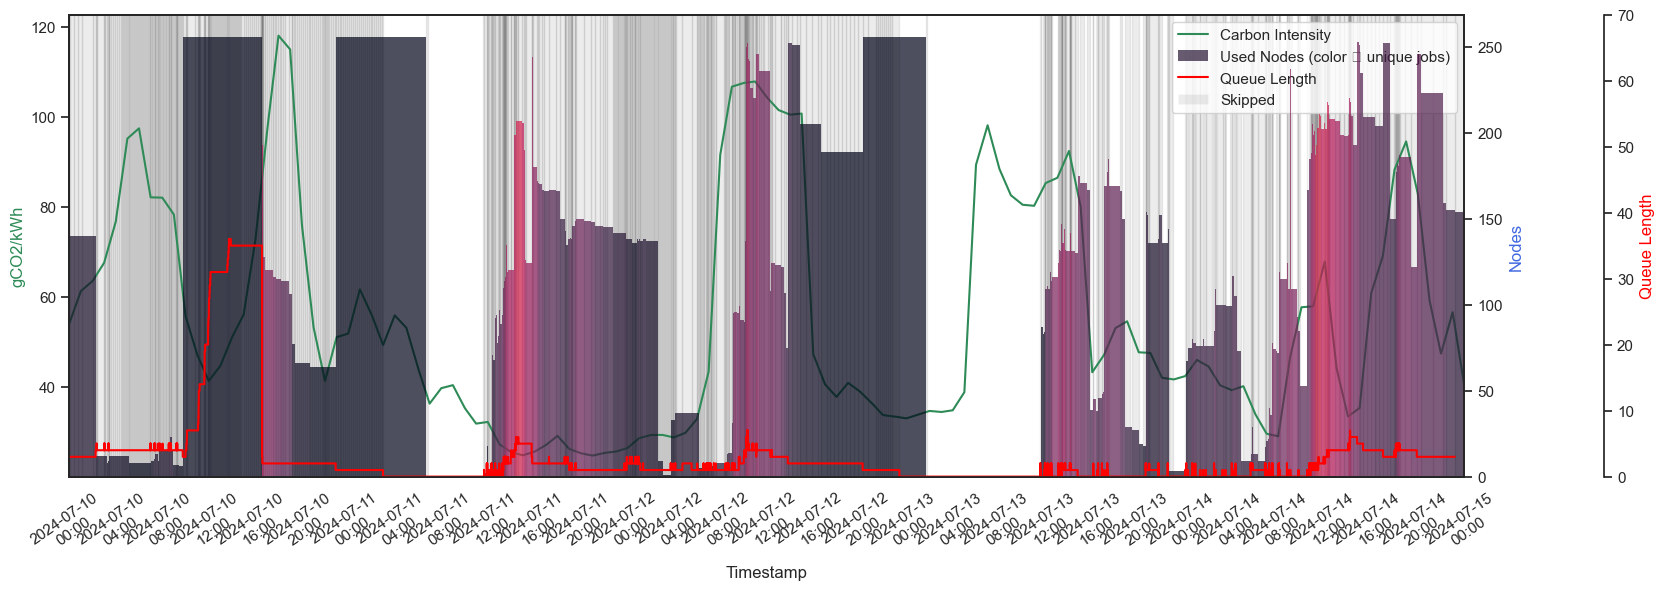

('renderings/seed_3_eta_0.5.png', <Figure size 1800x600 with 3 Axes>)

/Users/mikkeldahl/green-hpc-scheduler/.venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  func(*args, **kwargs)


In [ ]:
from src.validation import Validation
val = Validation()
val.load_dir(model_dir=train_and_eval_folder)
val.render_timeseries_plot(model_eval[1]["raw"]['model']['action_traces'], start_time = 3600*24*100, end_time = 3600*24*105, name = "seed_3_eta_0.5",  display_carbon_itensity=True, max_queue_length=70, mode ="test")

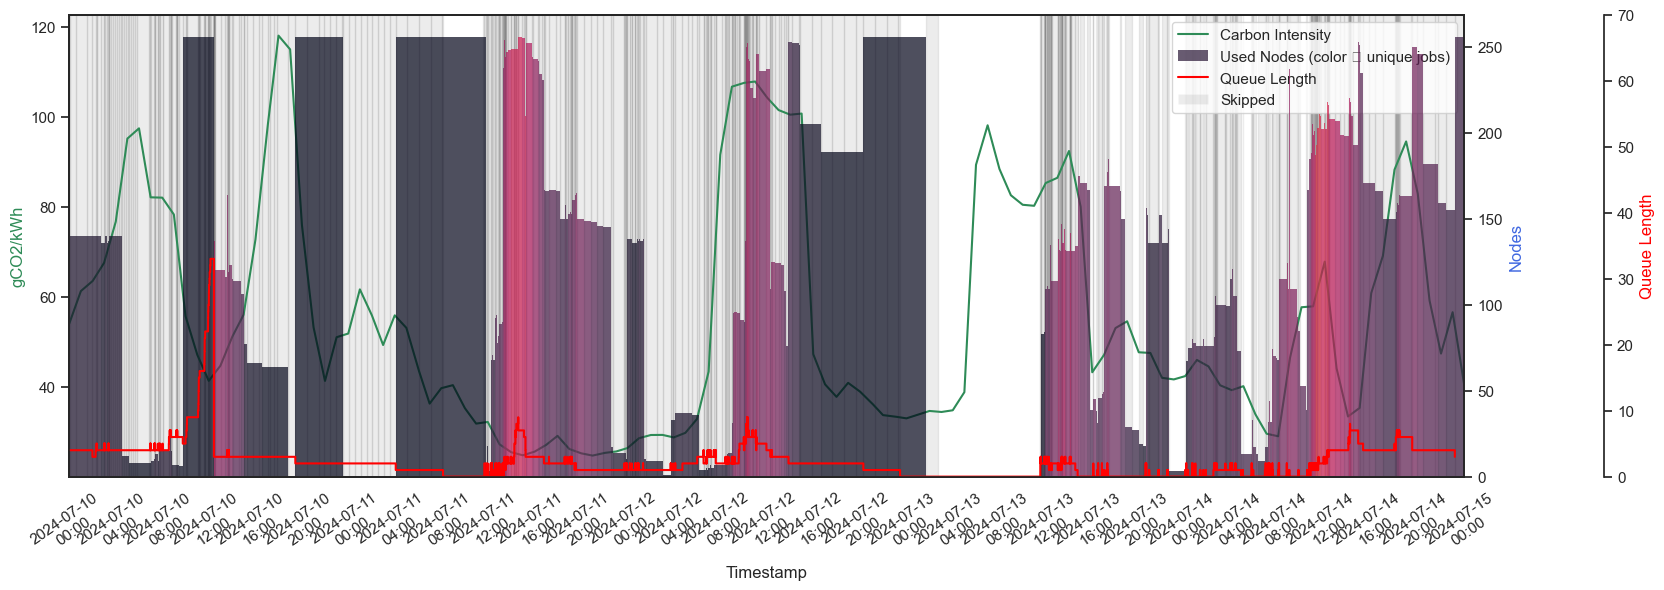

('renderings/seed_3_eta_0.5.png', <Figure size 1800x600 with 3 Axes>)

In [ ]:
from src.validation import Validation
val = Validation()
val.load_dir(model_dir=train_and_eval_folder)
val.render_timeseries_plot(

    model_eval_eta_mid[1]["raw"]['model']['action_traces'], start_time = 3600*24*100, end_time = 3600*24*105, name = "seed_3_eta_0.5",  display_carbon_itensity=True, max_queue_length=70, calendar_split="test",    mode="test",)

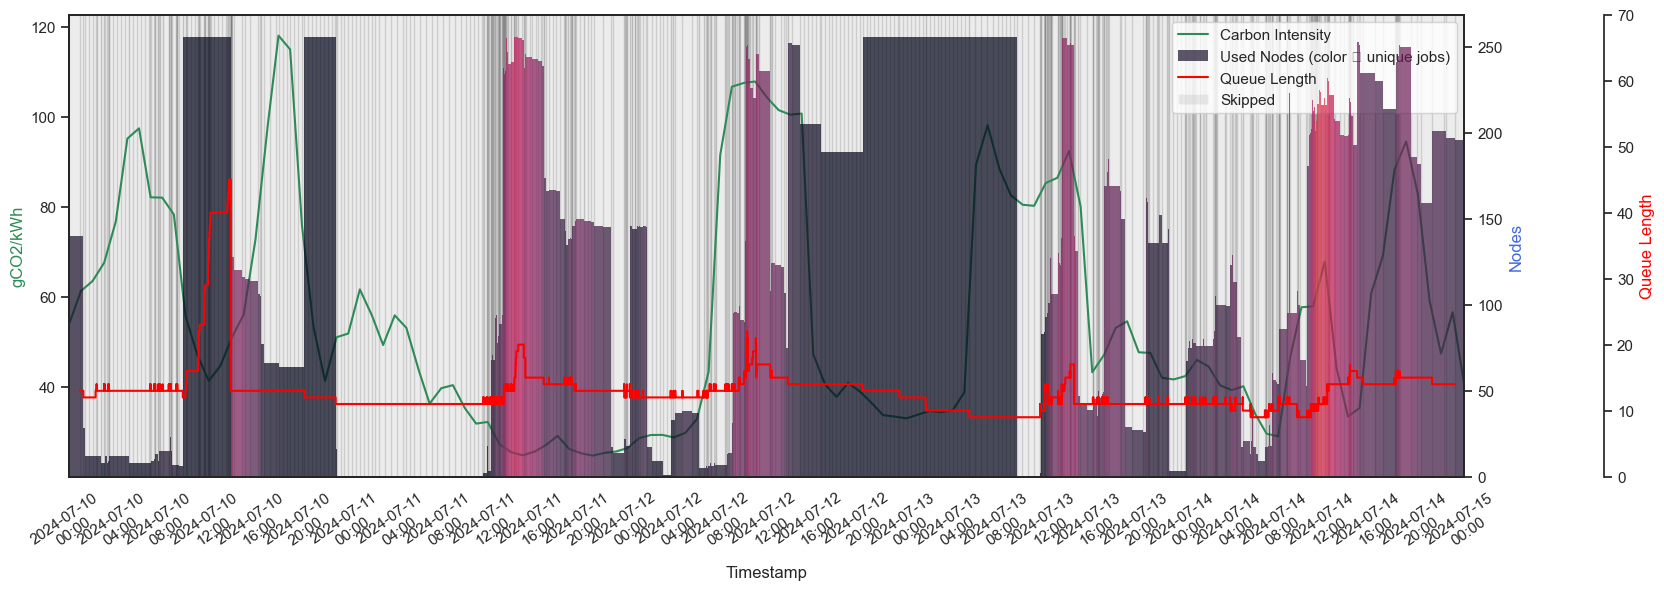

('renderings/seed_3_eta_0.5.png', <Figure size 1800x600 with 3 Axes>)

In [ ]:
from src.validation import Validation
val = Validation()
val.load_dir(model_dir=train_and_eval_folder)
val.render_timeseries_plot(model_eval_eta_low[4]["raw"]['model']['action_traces'], start_time = 3600*24*100, end_time = 3600*24*105, name = "seed_3_eta_0.5",  display_carbon_itensity=True, max_queue_length=70, calendar_split="test",    mode="test",)

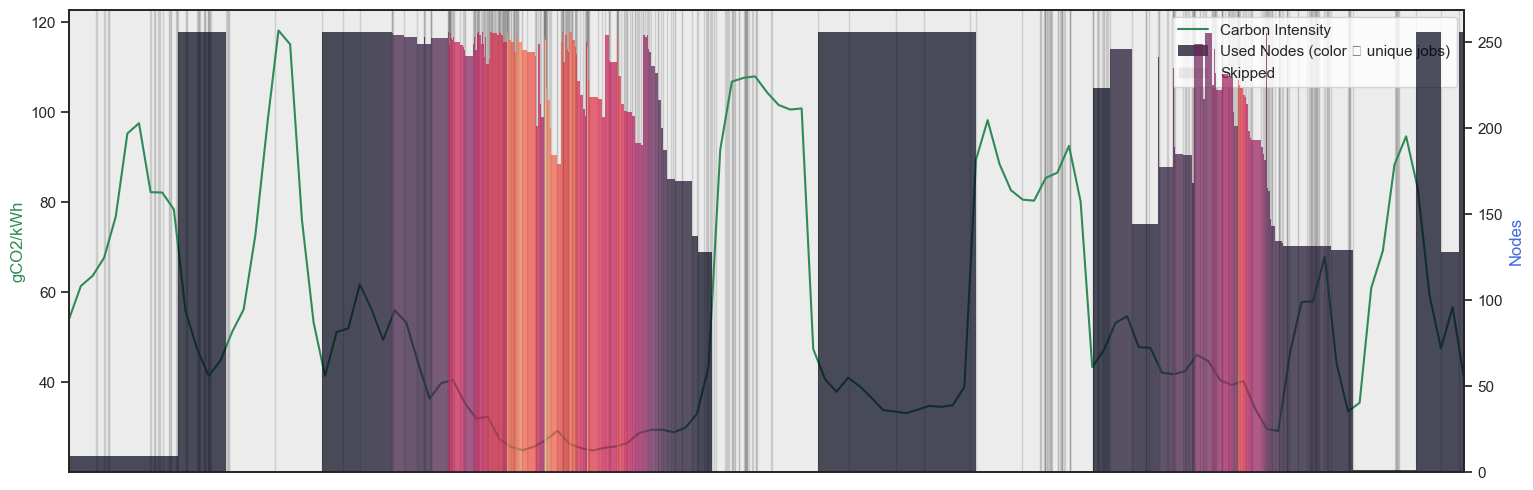

('renderings/seed_3_eta_0.5.png', <Figure size 1800x600 with 2 Axes>)

In [ ]:
from src.validation import Validation
val = Validation()
val.load_dir(model_dir=train_and_eval_folder)
val.render_timeseries_plot(model_eval_eta_very_low[1]["raw"]['model']['action_traces'], start_time = 3600*24*100, end_time = 3600*24*105, name = "seed_3_eta_0.5",  display_carbon_itensity=True, max_queue_length=3000, calendar_split="test",  display_queue=False,  mode="test", display_timestamps=False)

In [ ]:

from src.analysis import carbon_intensity_distribution
from src.analysis import evaluate_models, evaluate_baselines
## 0.0001
model_eval_eta_very_low = evaluate_models(
    train_eval_dir="results/ghs_sessions_20251020/delay_eta_0.0001/user_ci_disabled/eta_0.0001",
    seeds=[1],
    mode="test",
    n_eval_episodes=1,
)


baseline_eval = evaluate_baselines(
    train_eval_dir=train_and_eval_folder,
    mode="test",
    n_eval_episodes=1,
    include_percentiles=False,
)

dist = carbon_intensity_distribution(
    model_eval_eta_low[4]["raw"]['model']['action_traces'],
    mode="test",
    bins=40,
    normalize=True,
)

Current secounds after start:  3119201
1623
Current secounds after start:  5276587
5426
Current secounds after start:  8652145
8451
Current secounds after start:  11800926
11722
Current secounds after start:  14192311
15397
Current secounds after start:  17238074
18330
Current secounds after start:  21608731
21950
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking dela

TypeError: Each action trace entry must provide dict-like access via .get().